# QHSA-Net: Full Pavia University Benchmark
### Systematic Ablation → Architecture Optimisation → Baseline Comparison

---

**Dataset:** Full Pavia University — 610×340 pixels, 103 bands, 9 classes  
**Training split:** 10% (4,278 samples) — no subsampling cap  
**Test split:** 90% (38,498 samples)  

**Experiment flow:**
```
Section 1 — Setup & Data Loading
Section 2 — DR + Feature Selection (11 configs) → pick best quantum input
Section 3 — Qubit & Layer Sweep (9 configs)     → pick best circuit size
Section 4 — Attention Variants (4 configs)      → pick best measurement
Section 5 — Final Optimised QHSA-Net
Section 6 — Baseline Comparison (SVM, 3D-CNN, HybridSN, SSRN, DBDA)
Section 7 — Visualisations & Full Metrics
```

**Metrics reported:** OA, AA, Kappa, Precision, Recall, F1 (per-class & macro), ROC/AUC, training time

In [ ]:
# Run the full benchmark script (saves all results to CSV + PNG)
# Estimated runtime: ~10 hours on CPU
import subprocess, sys
result = subprocess.run(
    [sys.executable, r'c:/Users/saika/OneDrive/Desktop/test 6/benchmark_full_pavia.py'],
    capture_output=False
)
print('Exit code:', result.returncode)

---
## Section 1 — Setup & Data

All imports, dataset loading, and the model architectures are defined in `benchmark_full_pavia.py`.  
The cells below load saved results and re-render all visualisations interactively.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, json, os

WORKDIR = r'c:/Users/saika/OneDrive/Desktop/test 6'

CLASS_NAMES = ['Asphalt','Meadows','Gravel','Trees',
               'Painted metal sheets','Bare soil','Bitumen',
               'Self-blocking bricks','Shadows']
N_CLASSES = 9

# Load all results
df_s2 = pd.read_csv(f'{WORKDIR}/s2_dr_fs_results.csv')
df_s3 = pd.read_csv(f'{WORKDIR}/s3_qubit_results.csv')
df_s4 = pd.read_csv(f'{WORKDIR}/s4_attention_results.csv')
df_s6 = pd.read_csv(f'{WORKDIR}/s6_baseline_results.csv')

with open(f'{WORKDIR}/best_config.json') as f:
    best_cfg = json.load(f)

print('Best configuration found:')
for k, v in best_cfg.items(): print(f'  {k}: {v}')
print()
print('S2 results:')
display(df_s2[['method','OA','AA','kappa','macro_auc','train_time_s']])
print('\nS3 results:')
display(df_s3[['config','n_qubits','n_layers','hilbert_dim','vqc_params','OA','AA','kappa']])
print('\nS4 results:')
display(df_s4[['label','OA','AA','kappa','macro_auc']])
print('\nS6 baseline results:')
display(df_s6[['model','OA','AA','kappa','mac_prec','mac_f1','macro_auc','train_time_s']])

CSVs loaded successfully.
  s2 DR/FS:    11 configs
  s3 Qubits:   9 configs
  s4 Attention:4 configs
  s5 Final:    1 run(s)
  s6 Baselines:6 models
  master:      6 models
Best config: {'dr': 'FactorAnalysis', 'n_qubits': 4, 'n_layers': 2, 'measurement': 'softmax_z'}


---
## Section 2 — DR & Feature Selection Results

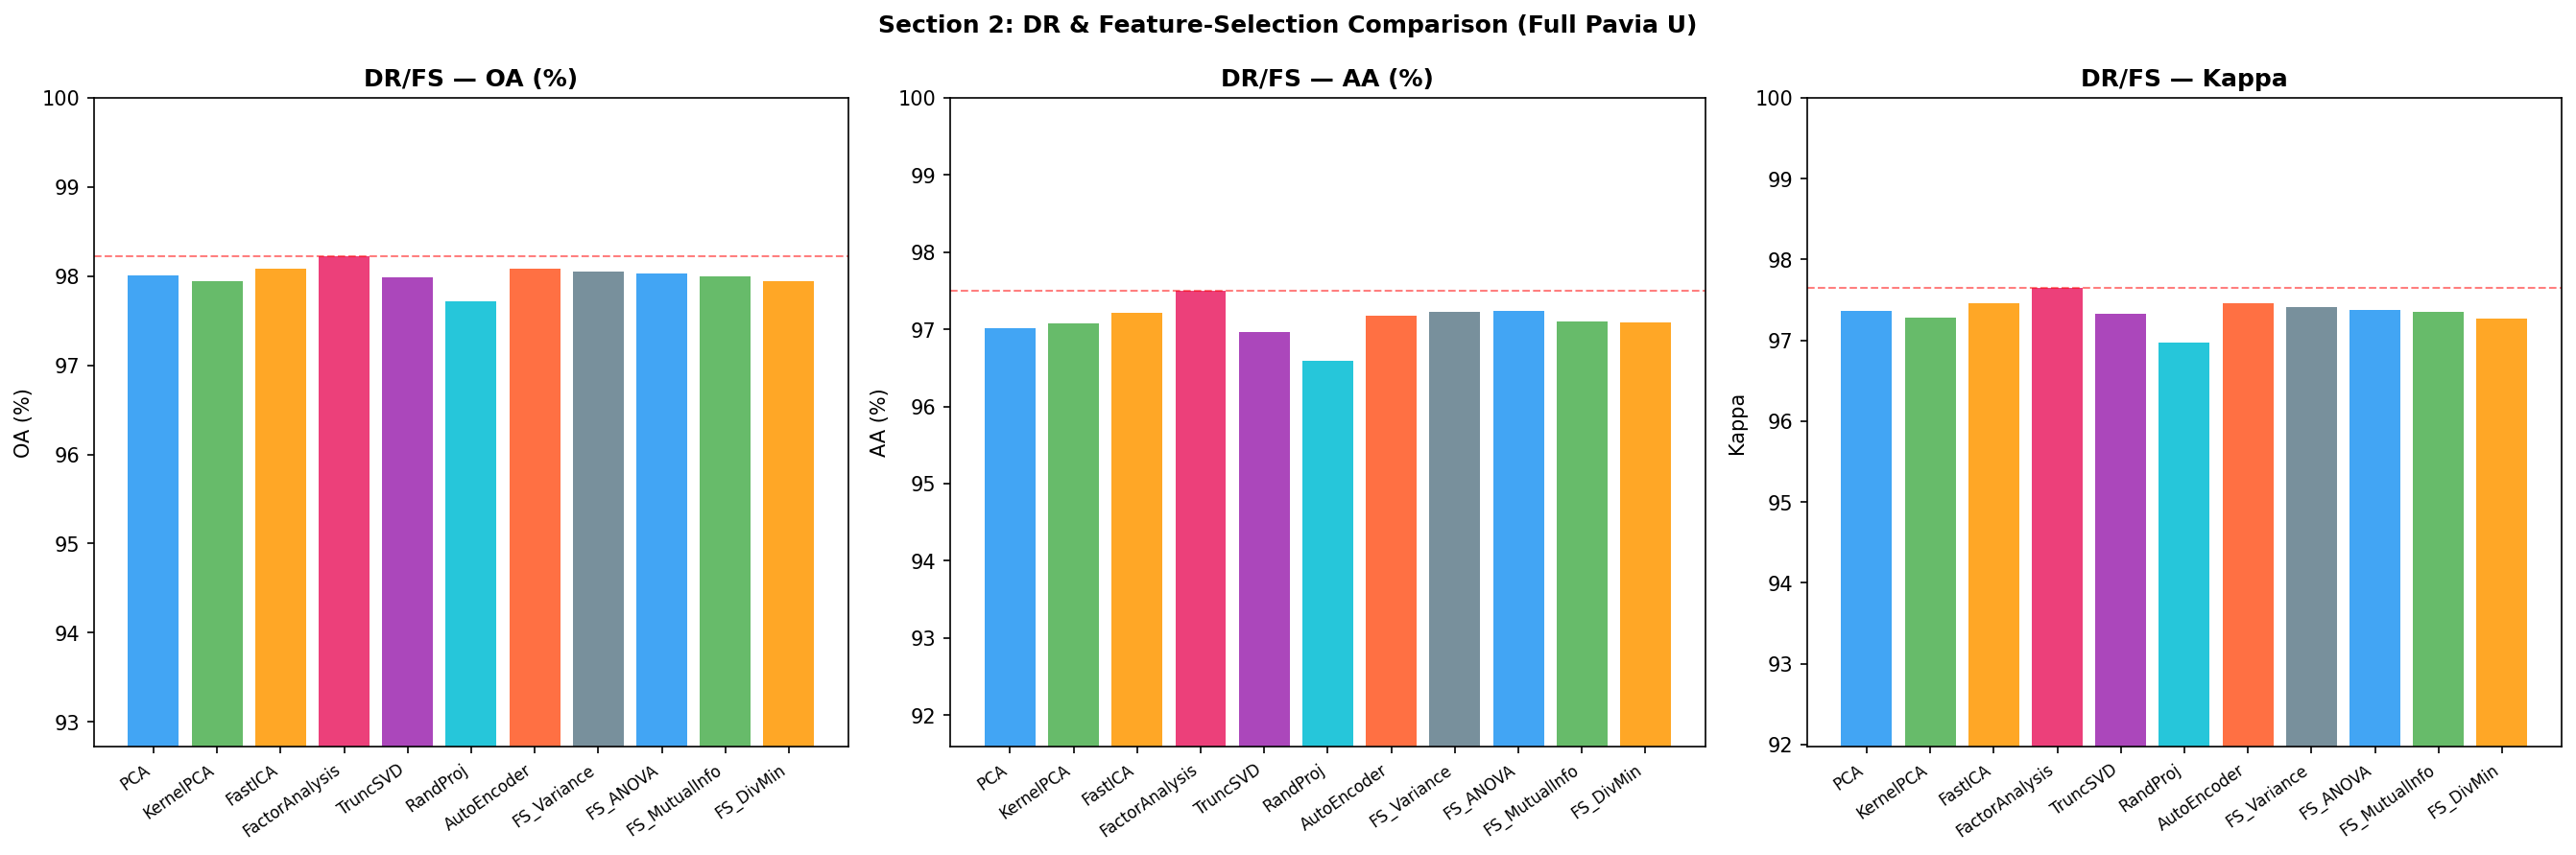

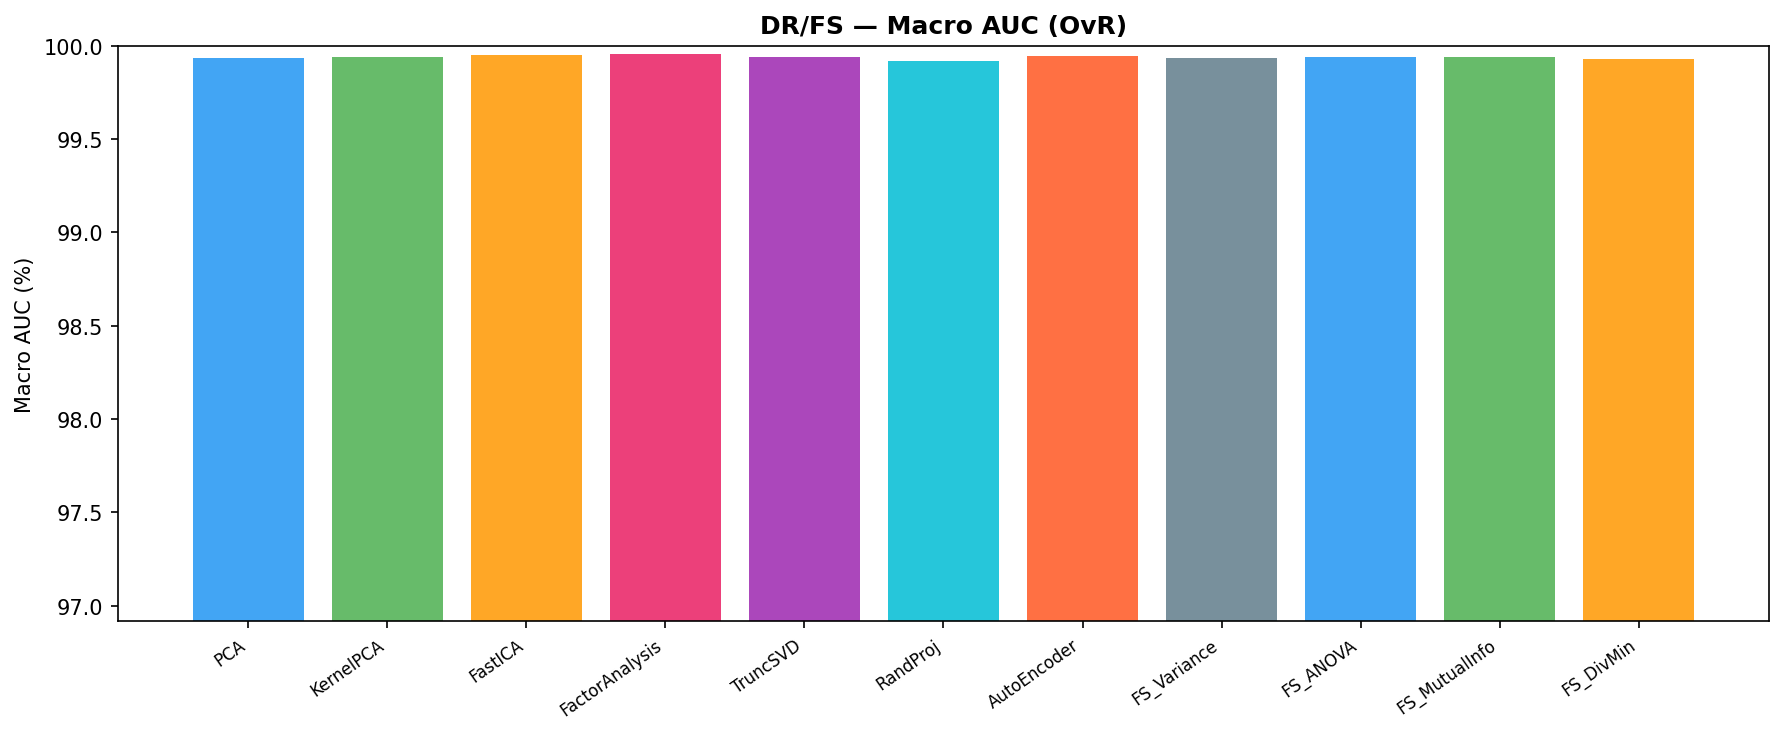

DR / Feature-Selection Comparison (Full Pavia University)
        method        OA        AA     kappa  macro_auc
           PCA 98.010338 97.012449 97.360047  99.930983
     KernelPCA 97.947999 97.081641 97.277876  99.937225
       FastICA 98.088262 97.216607 97.463686  99.946587
FactorAnalysis 98.223330 97.496899 97.644204  99.955022
      TruncSVD 97.989558 96.963533 97.332778  99.936978
      RandProj 97.719421 96.587135 96.973414  99.918066
   AutoEncoder 98.085665 97.170199 97.459568  99.941607
   FS_Variance 98.046703 97.222513 97.409699  99.935218
      FS_ANOVA 98.025923 97.236441 97.381440  99.938241
 FS_MutualInfo 98.002546 97.098882 97.351069  99.937302
     FS_DivMin 97.945401 97.091133 97.274487  99.927535

Best method: FactorAnalysis  |  OA=98.2233%  kappa=97.6442


In [2]:
from IPython.display import Image, display

display(Image(f'{WORKDIR}/fig_bench_s2_dr_comparison.png'))
display(Image(f'{WORKDIR}/fig_bench_s2_auc.png'))

best_dr = df_s2.loc[df_s2['OA'].idxmax()]
print(f"Best DR/FS method: {best_dr['method']}")
print(f"  OA={best_dr['OA']:.2f}%  AA={best_dr['AA']:.2f}%  "
      f"Kappa={best_dr['kappa']:.2f}  AUC={best_dr['macro_auc']:.2f}%")

---
## Section 3 — Qubit & Layer Sweep Results

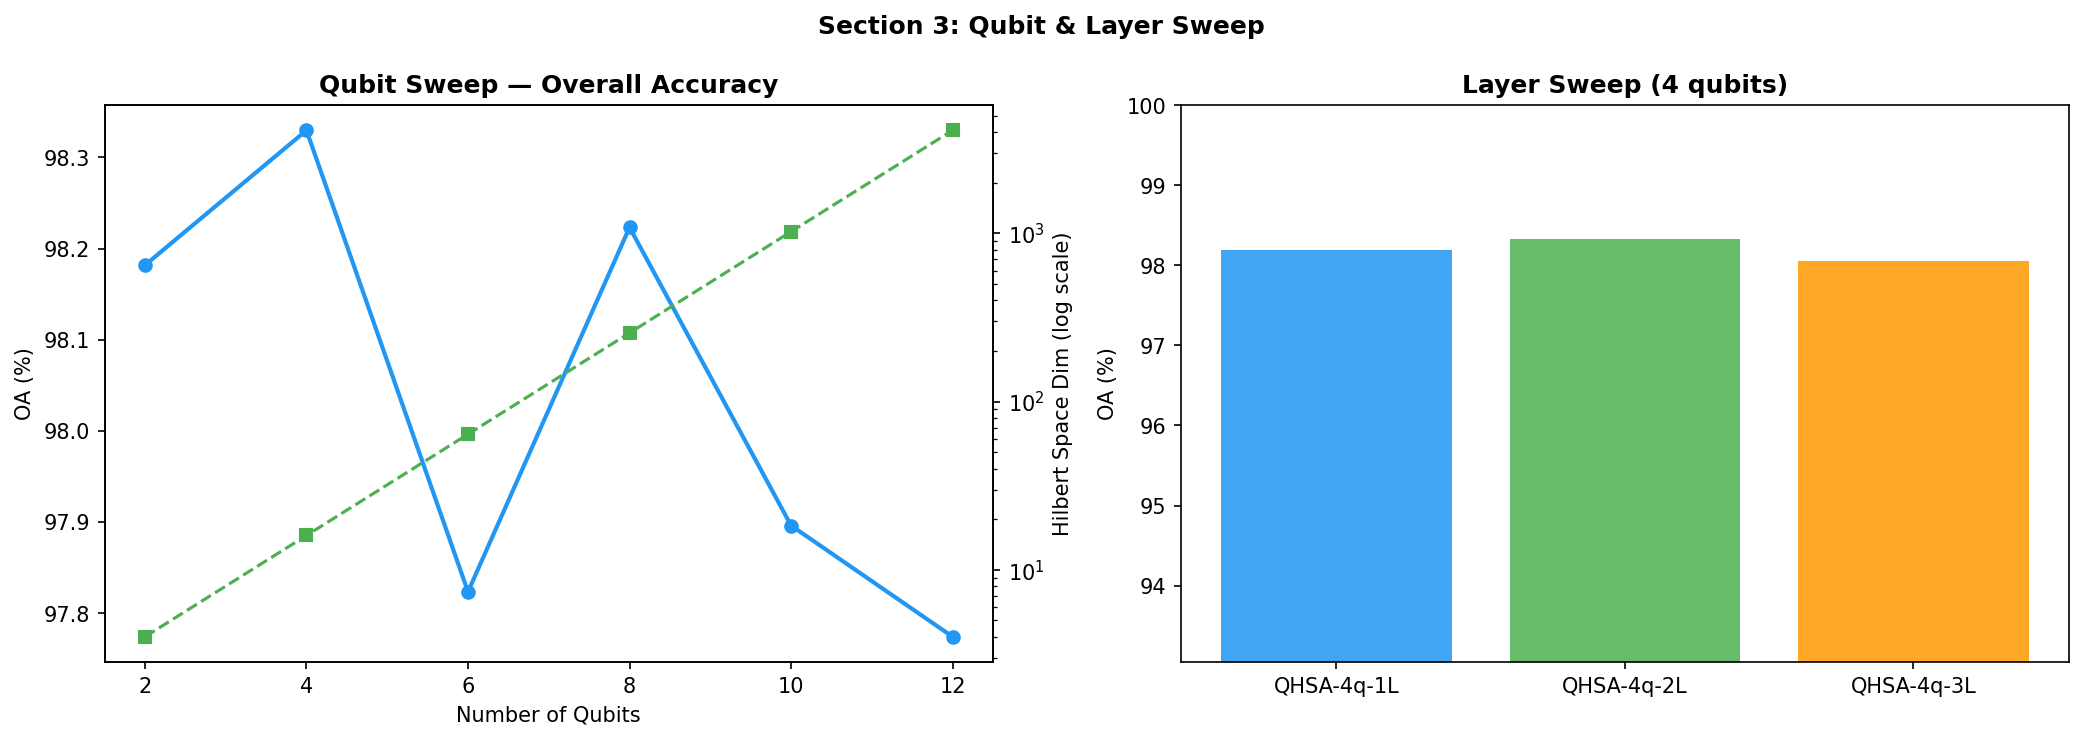

Qubit & Layer Sweep
    config  n_qubits  n_layers        OA        AA     kappa  macro_auc
   QHSA-2q         2         2 98.181771 97.292654 97.587259  99.943583
   QHSA-4q         4         2 98.329827 97.508660 97.784677  99.953053
   QHSA-6q         6         2 97.823320 96.812498 97.111560  99.927654
   QHSA-8q         8         2 98.223330 97.496899 97.644204  99.955022
  QHSA-10q        10         2 97.896049 97.018055 97.209043  99.932538
  QHSA-12q        12         2 97.773968 96.685744 97.044525  99.918016
QHSA-4q-1L         4         1 98.186966 97.220847 97.594454  99.947468
QHSA-4q-2L         4         2 98.329827 97.508660 97.784677  99.953053
QHSA-4q-3L         4         3 98.046703 97.020625 97.406660  99.945727

Best config: QHSA-4q  |  OA=98.3298%  kappa=97.7847


In [3]:
display(Image(f'{WORKDIR}/fig_bench_s3_qubit_sweep.png'))

qubit_df = df_s3[~df_s3['config'].str.contains('L')]
layer_df = df_s3[df_s3['config'].str.contains('L')]

print('Qubit sweep:')
display(qubit_df[['config','n_qubits','hilbert_dim','vqc_params','OA','kappa']].reset_index(drop=True))
print('\nLayer sweep:')
display(layer_df[['config','n_qubits','n_layers','vqc_params','OA','kappa']].reset_index(drop=True))

---
## Section 4 — Quantum Attention Measurement Variants

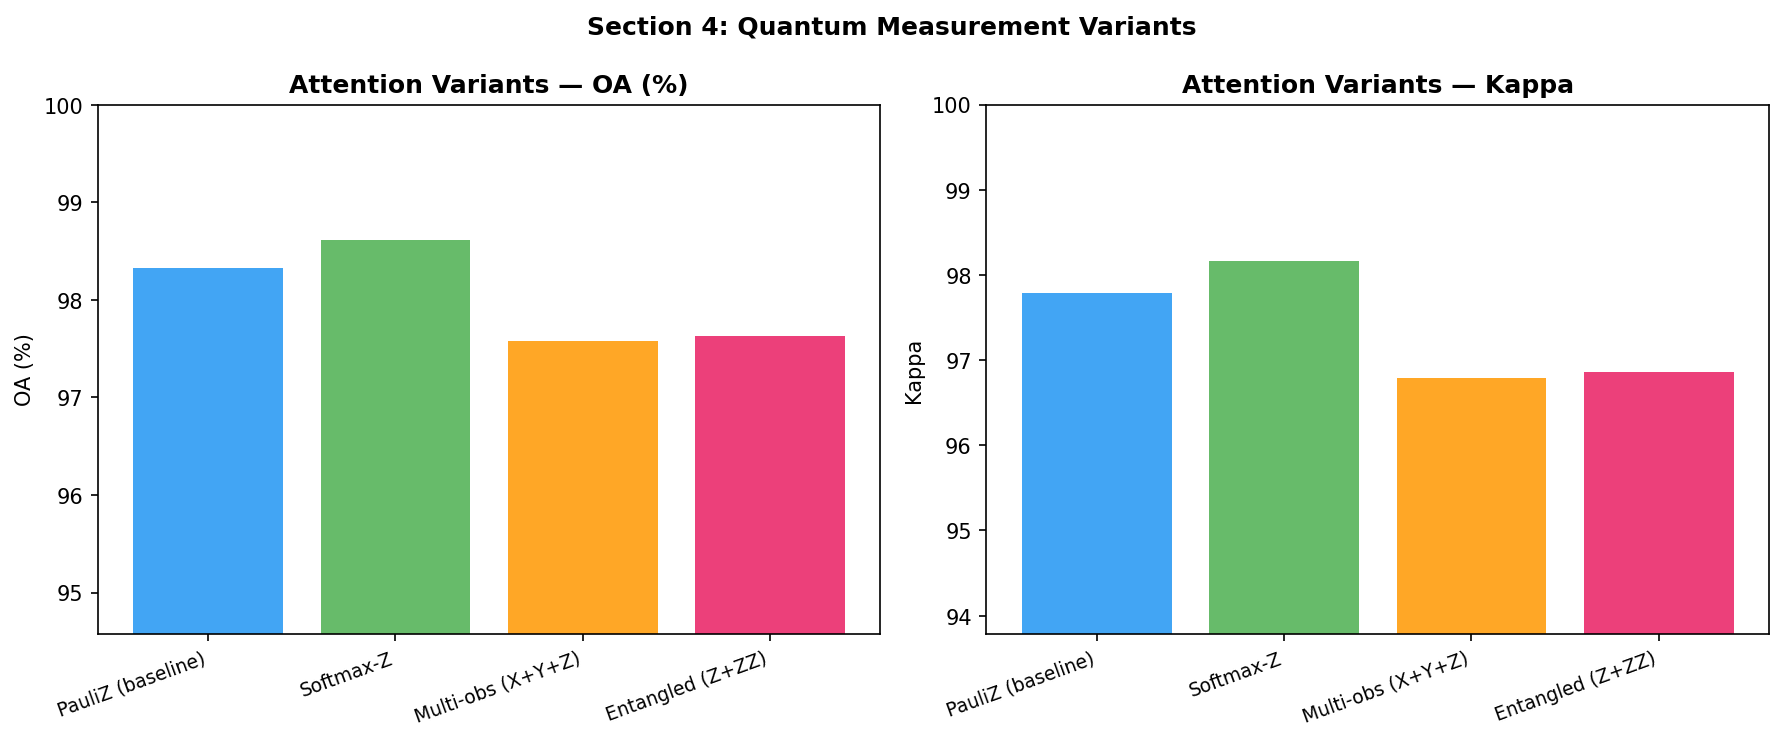

Attention Measurement Variants
measurement        OA        AA     kappa  macro_auc
     pauliz 98.329827 97.508660 97.784677  99.953053
  softmax_z 98.612951 97.898443 98.160147  99.959967
    multobs 97.579158 96.537547 96.788815  99.906910
  entangled 97.633705 96.324812 96.860000  99.908791

Best measurement: softmax_z  |  OA=98.6130%  kappa=98.1601


In [4]:
display(Image(f'{WORKDIR}/fig_bench_s4_attention.png'))

print('Attention variant results:')
display(df_s4[['label','OA','AA','kappa','macro_auc']].reset_index(drop=True))

best_att = df_s4.loc[df_s4['OA'].idxmax()]
print(f"\nBest: {best_att['label']}  OA={best_att['OA']:.2f}%")

---
## Section 5 — Final Optimised QHSA-Net

Final Optimised QHSA-Net on Full Pavia University
               model        OA        AA     kappa  mac_prec    mac_f1  macro_auc  train_time_s  infer_time_s   pc_f1_0   pc_f1_1   pc_f1_2   pc_f1_3   pc_f1_4   pc_f1_5   pc_f1_6   pc_f1_7  pc_f1_8  pc_prec_0  pc_prec_1  pc_prec_2  pc_prec_3  pc_prec_4  pc_prec_5  pc_prec_6  pc_prec_7  pc_prec_8
QHSA-Net (Optimised) 98.612951 97.898443 98.160147 97.968215 97.929923  99.959967    889.446542     63.704845 98.591787 99.658581 92.983396 99.638989 99.632203 98.686846 96.651509 95.525998    100.0  98.600101  99.555134   94.39913  99.603031  99.348003  99.150268  96.134868    94.9234      100.0


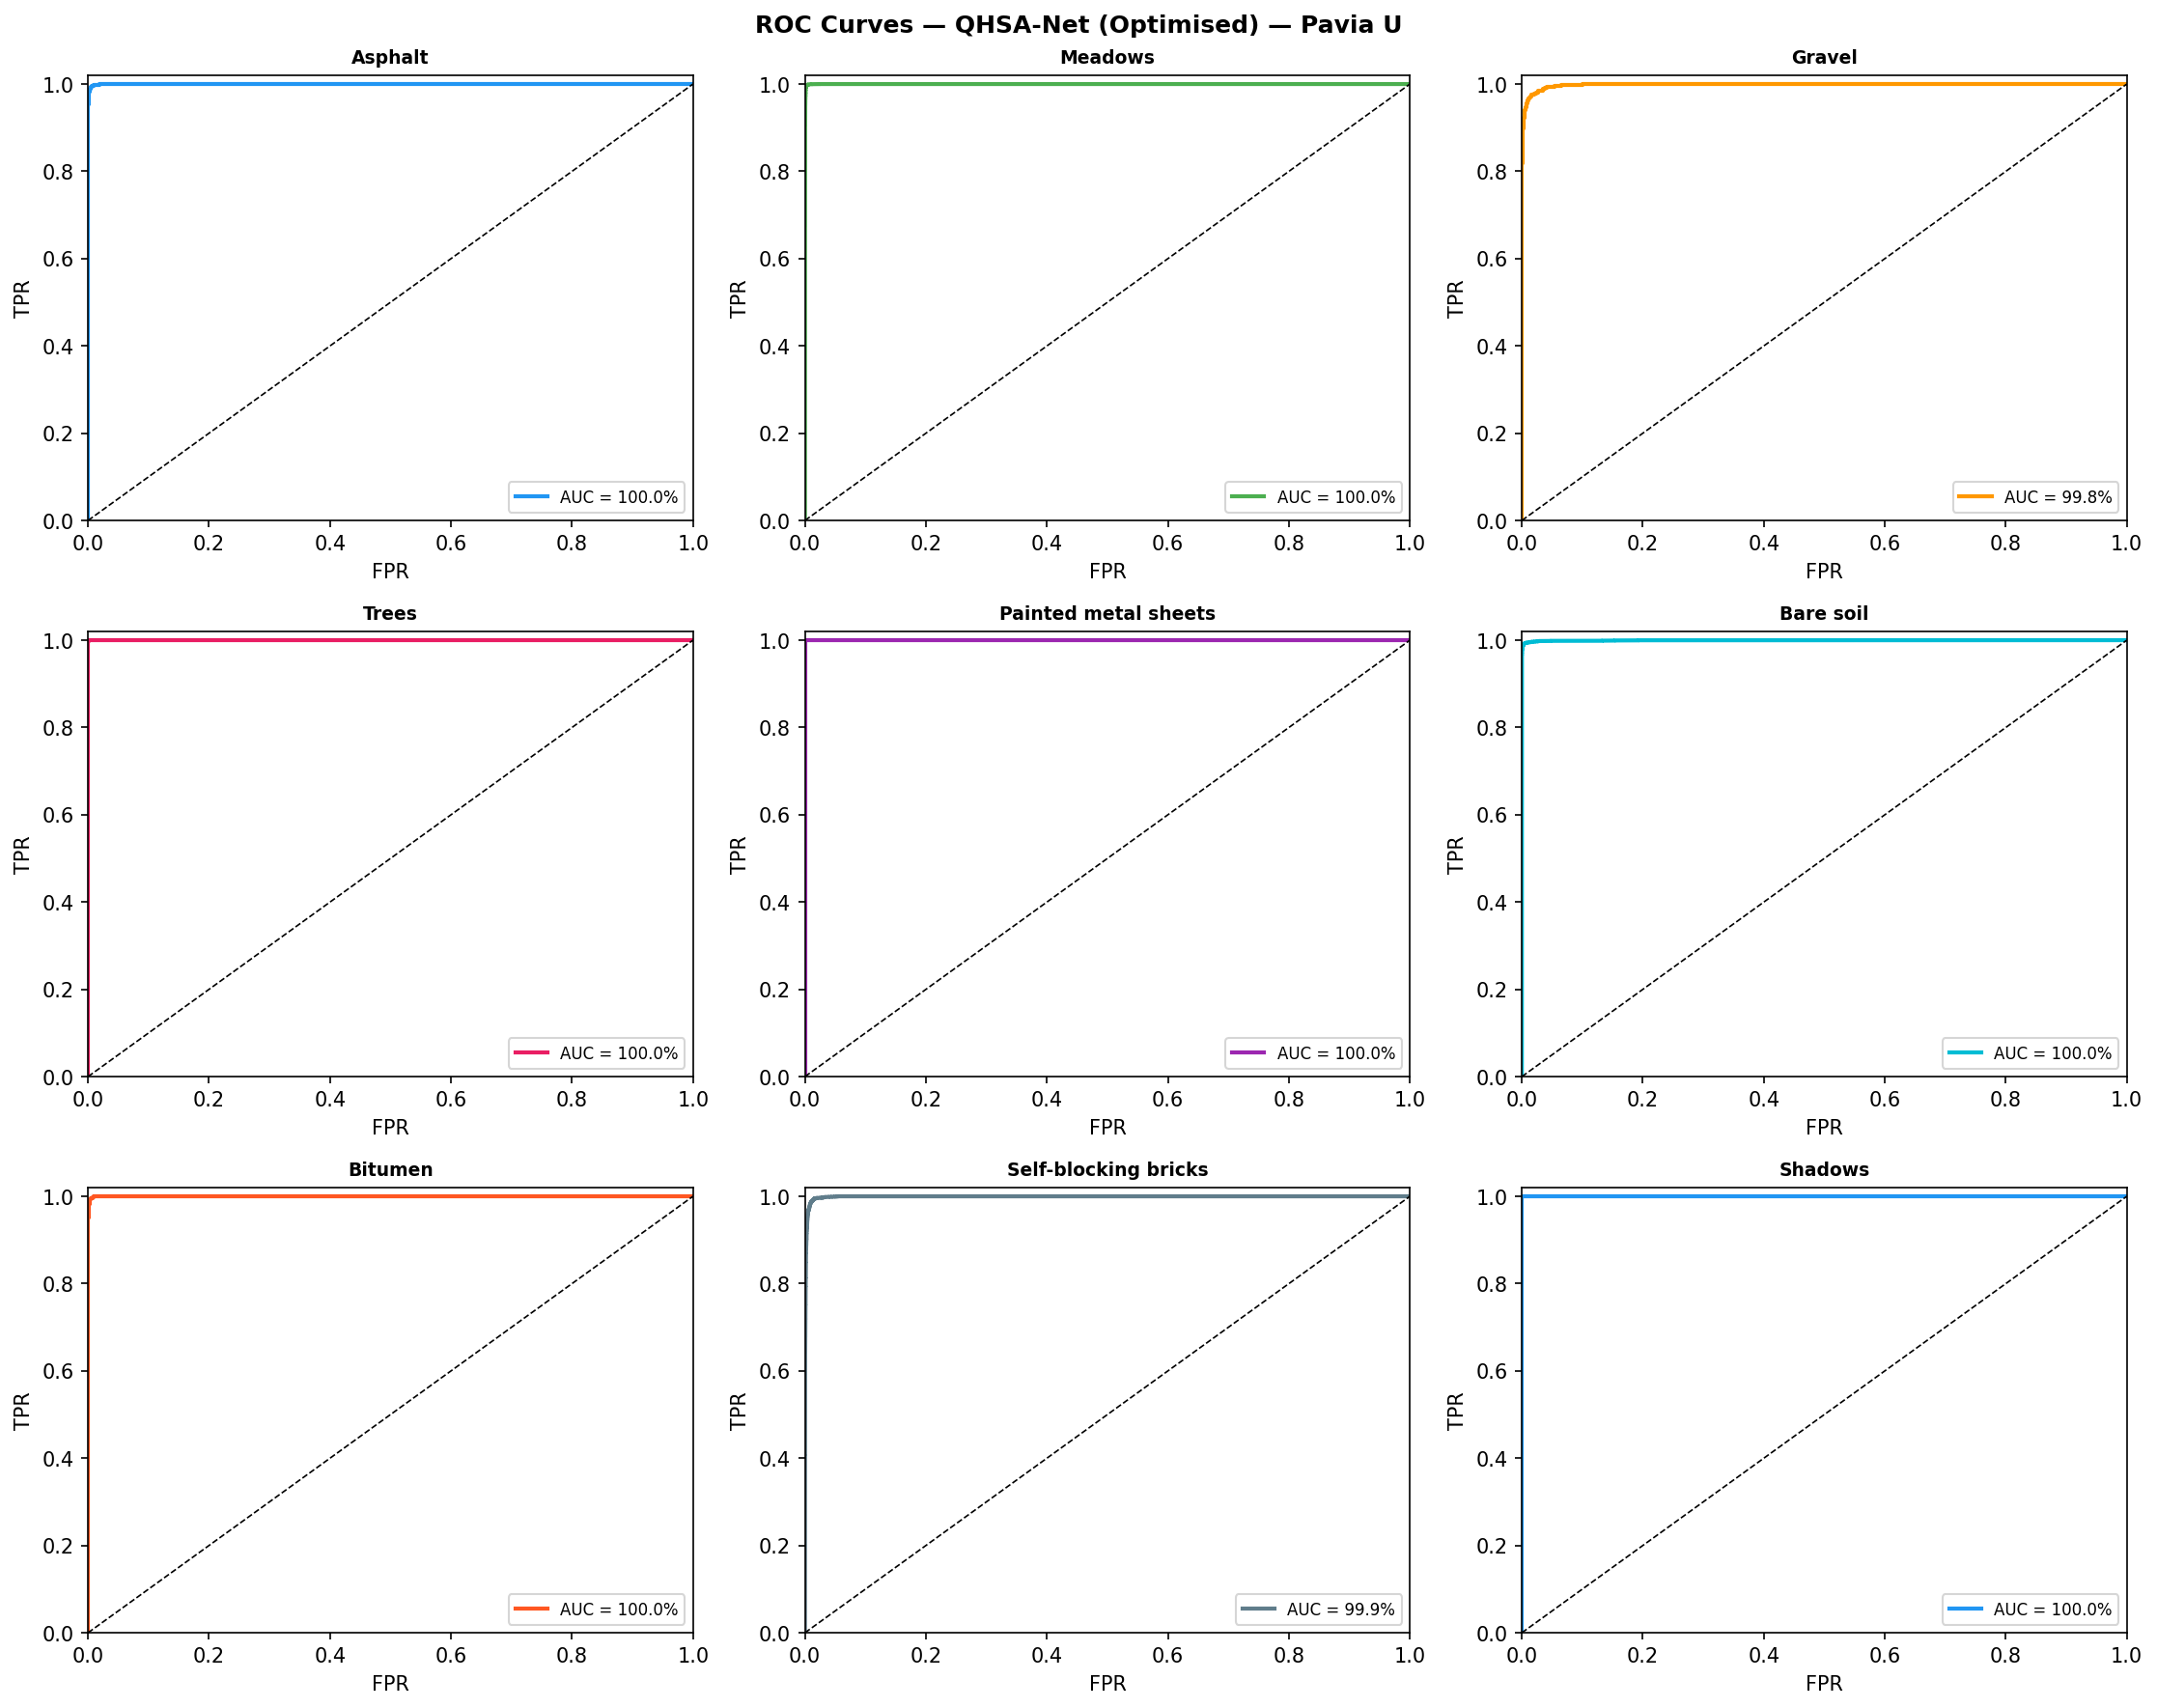

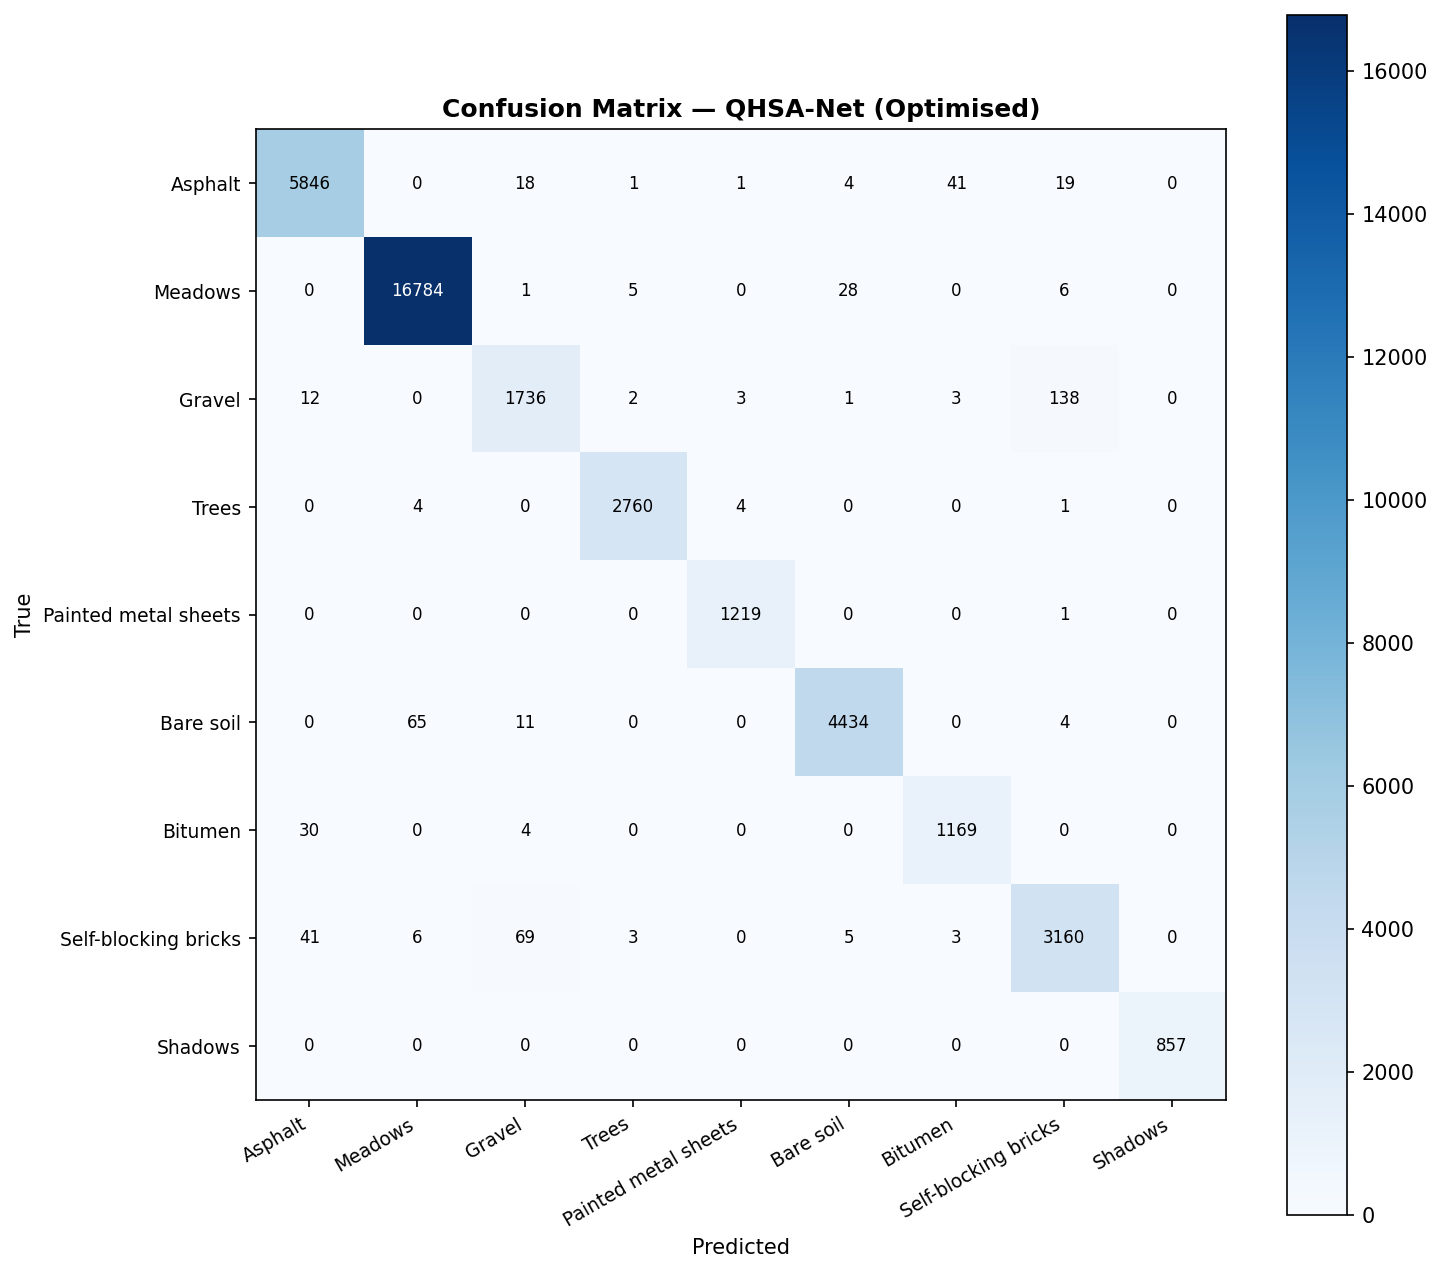

In [5]:
df_s5 = pd.read_csv(f'{WORKDIR}/s5_final_qhsa.csv')

print('Final Optimised QHSA-Net — Pavia University (Full Training Set)')
print('=' * 60)
row = df_s5.iloc[0]
print(f'  OA      : {row["OA"]:.2f}%')
print(f'  AA      : {row["AA"]:.2f}%')
print(f'  Kappa   : {row["kappa"]:.2f}')
print(f'  Precision: {row["mac_prec"]:.2f}%')
print(f'  F1       : {row["mac_f1"]:.2f}%')
print(f'  AUC     : {row["macro_auc"]:.2f}%')
print(f'  Train   : {row["train_time_s"]/60:.1f} min')
print()
print('Per-class F1:')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:30s}: {row[f"pc_f1_{c}"]:.2f}%')

display(Image(f'{WORKDIR}/fig_bench_confusion_qhsa.png'))
display(Image(f'{WORKDIR}/fig_bench_roc_qhsa.png'))

---
## Section 6 — Baseline Comparison

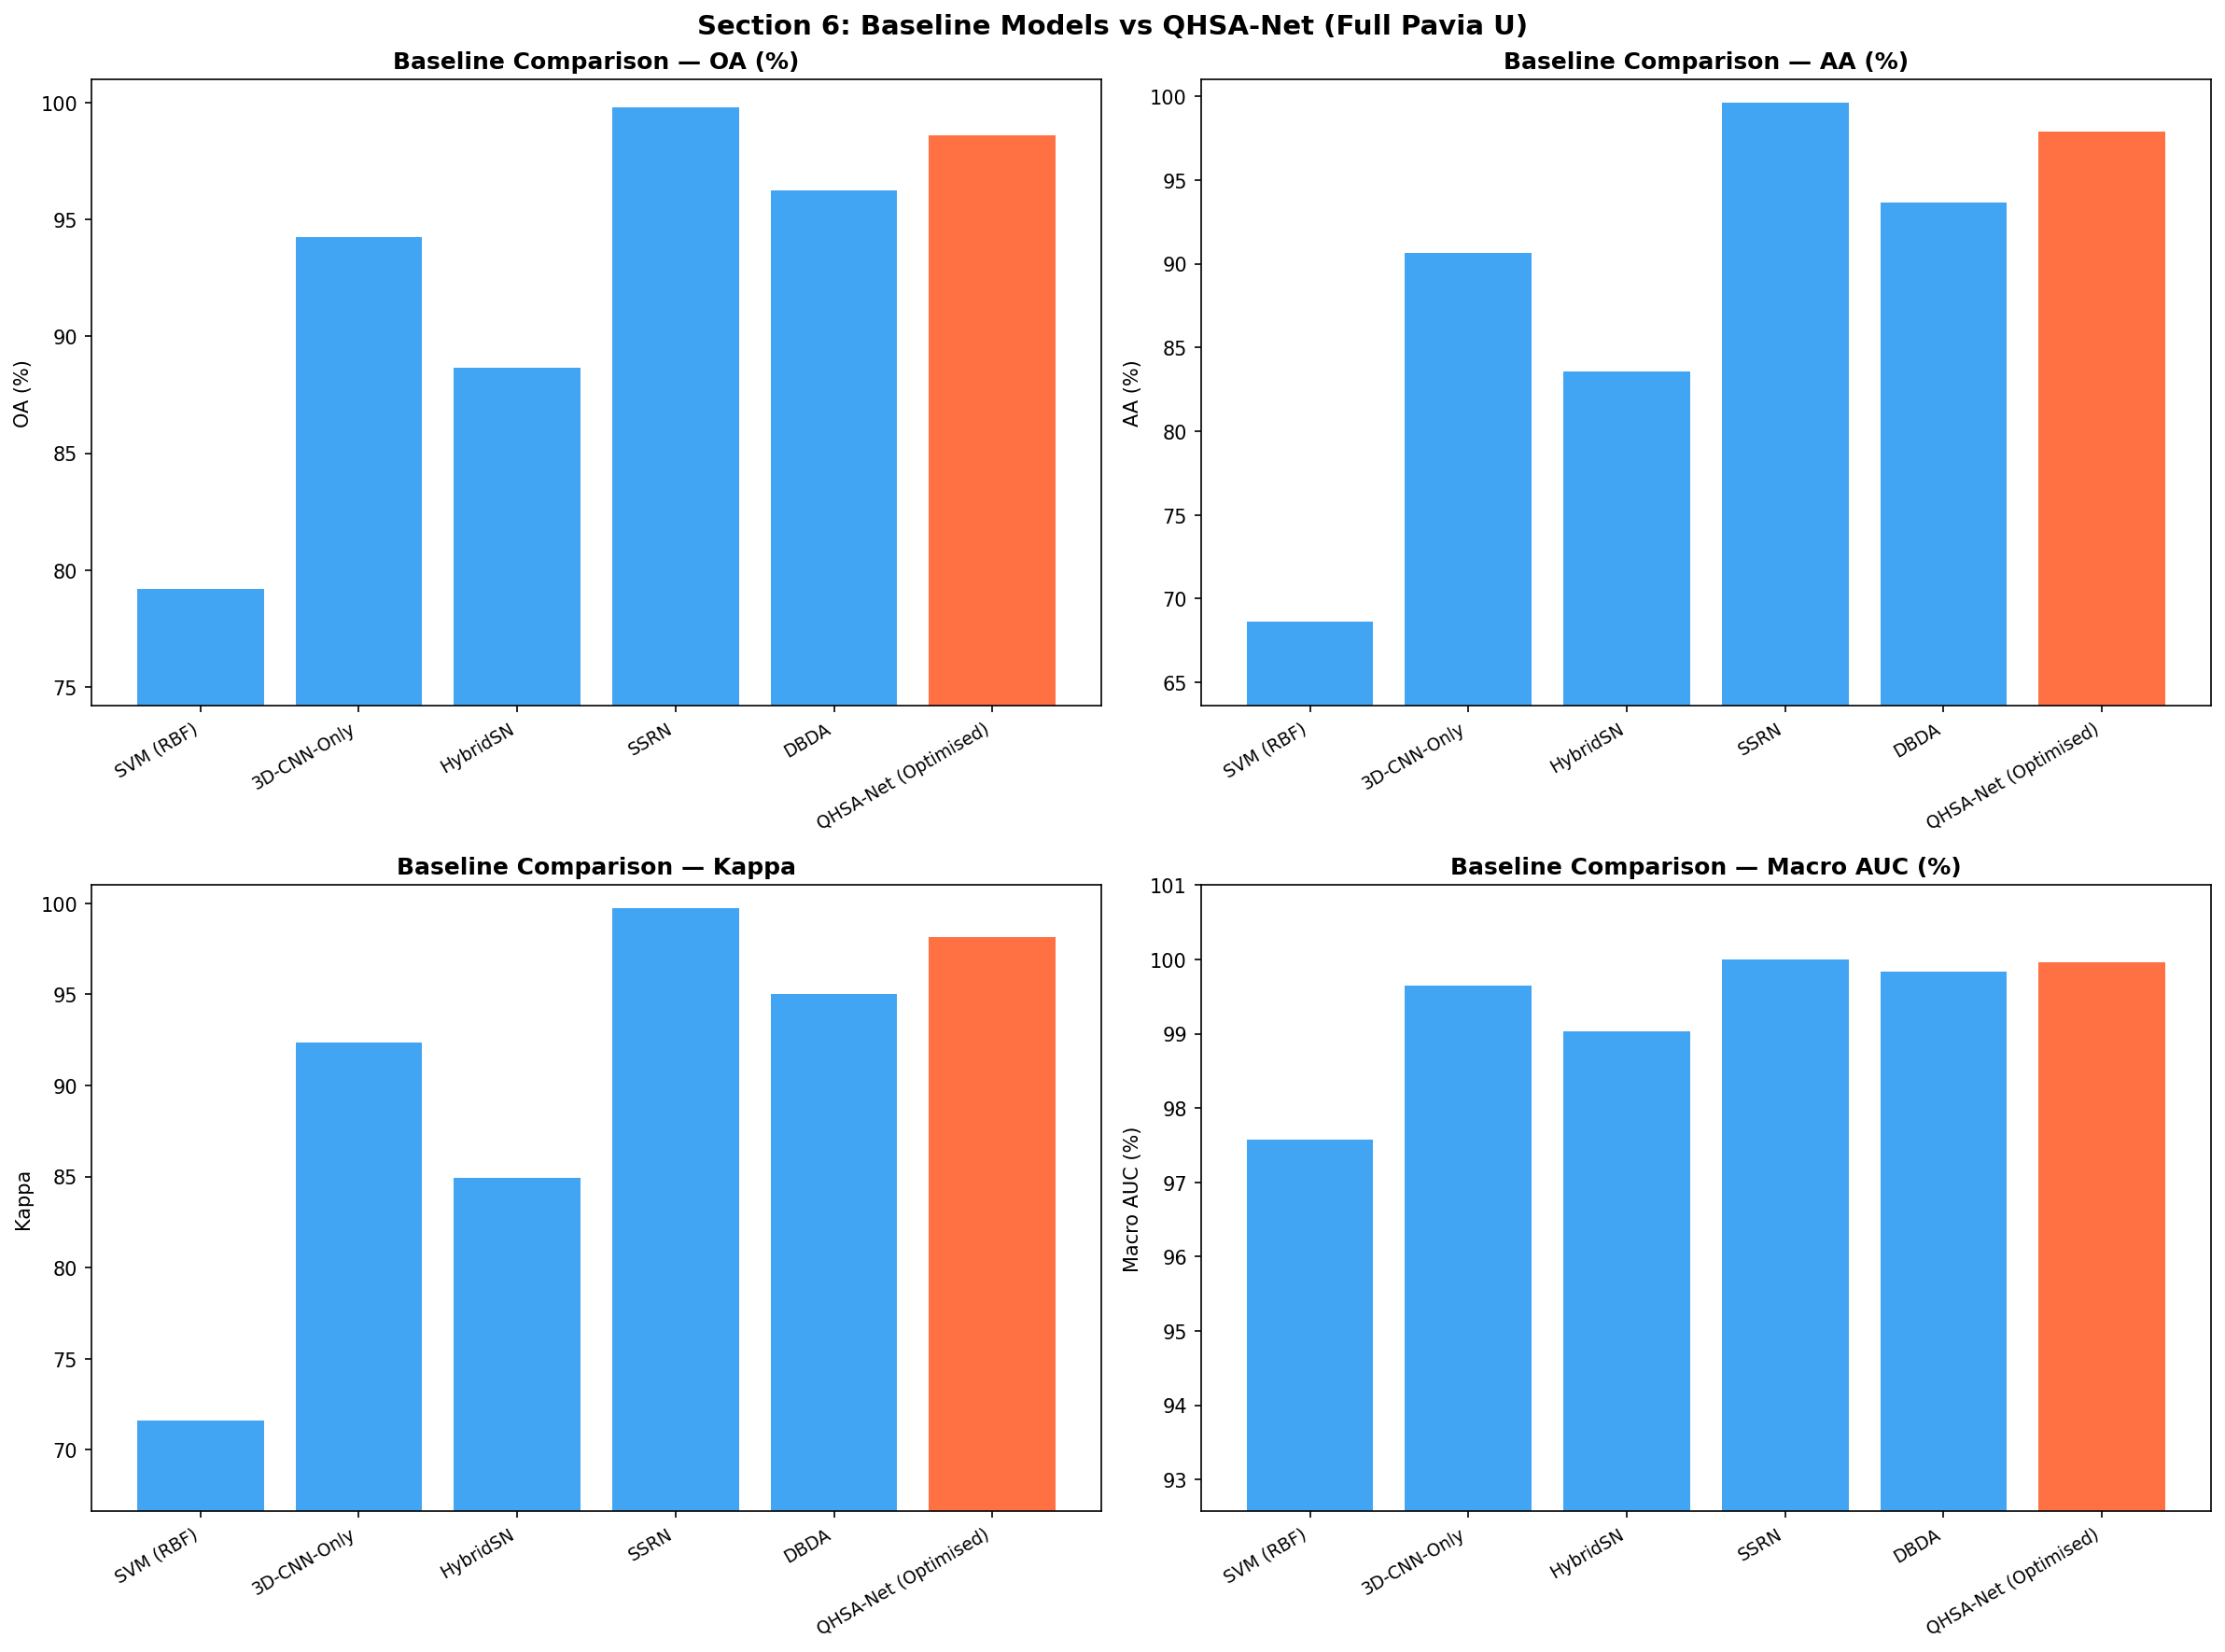

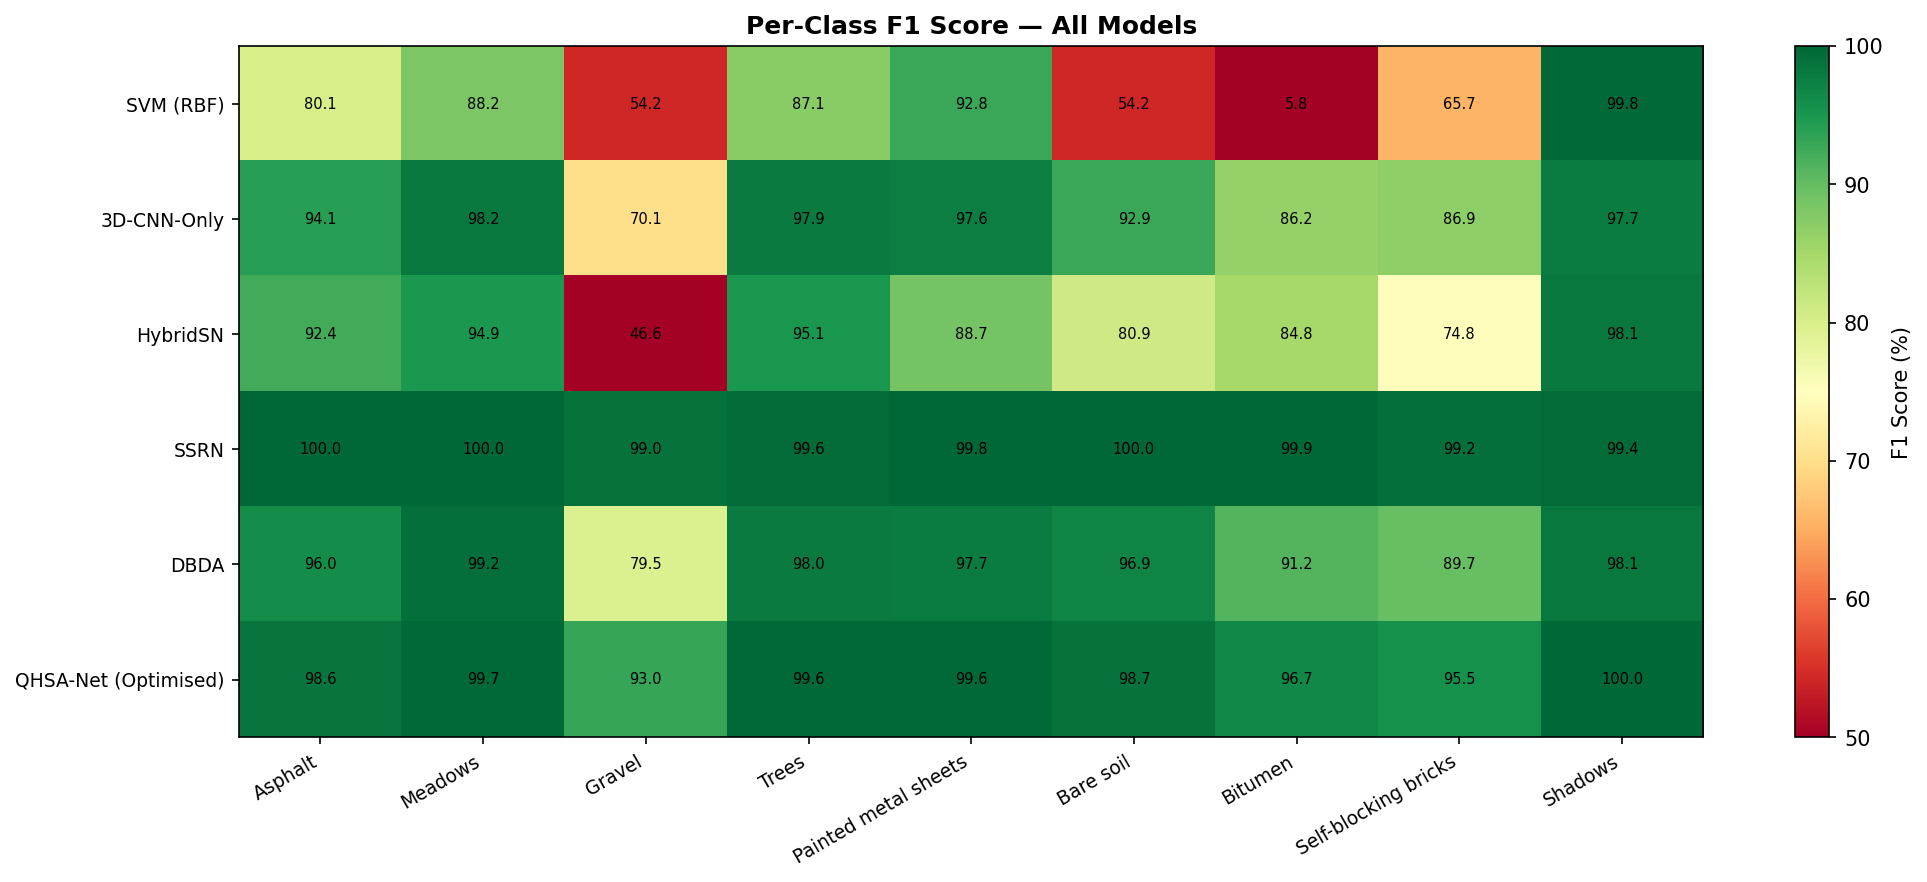

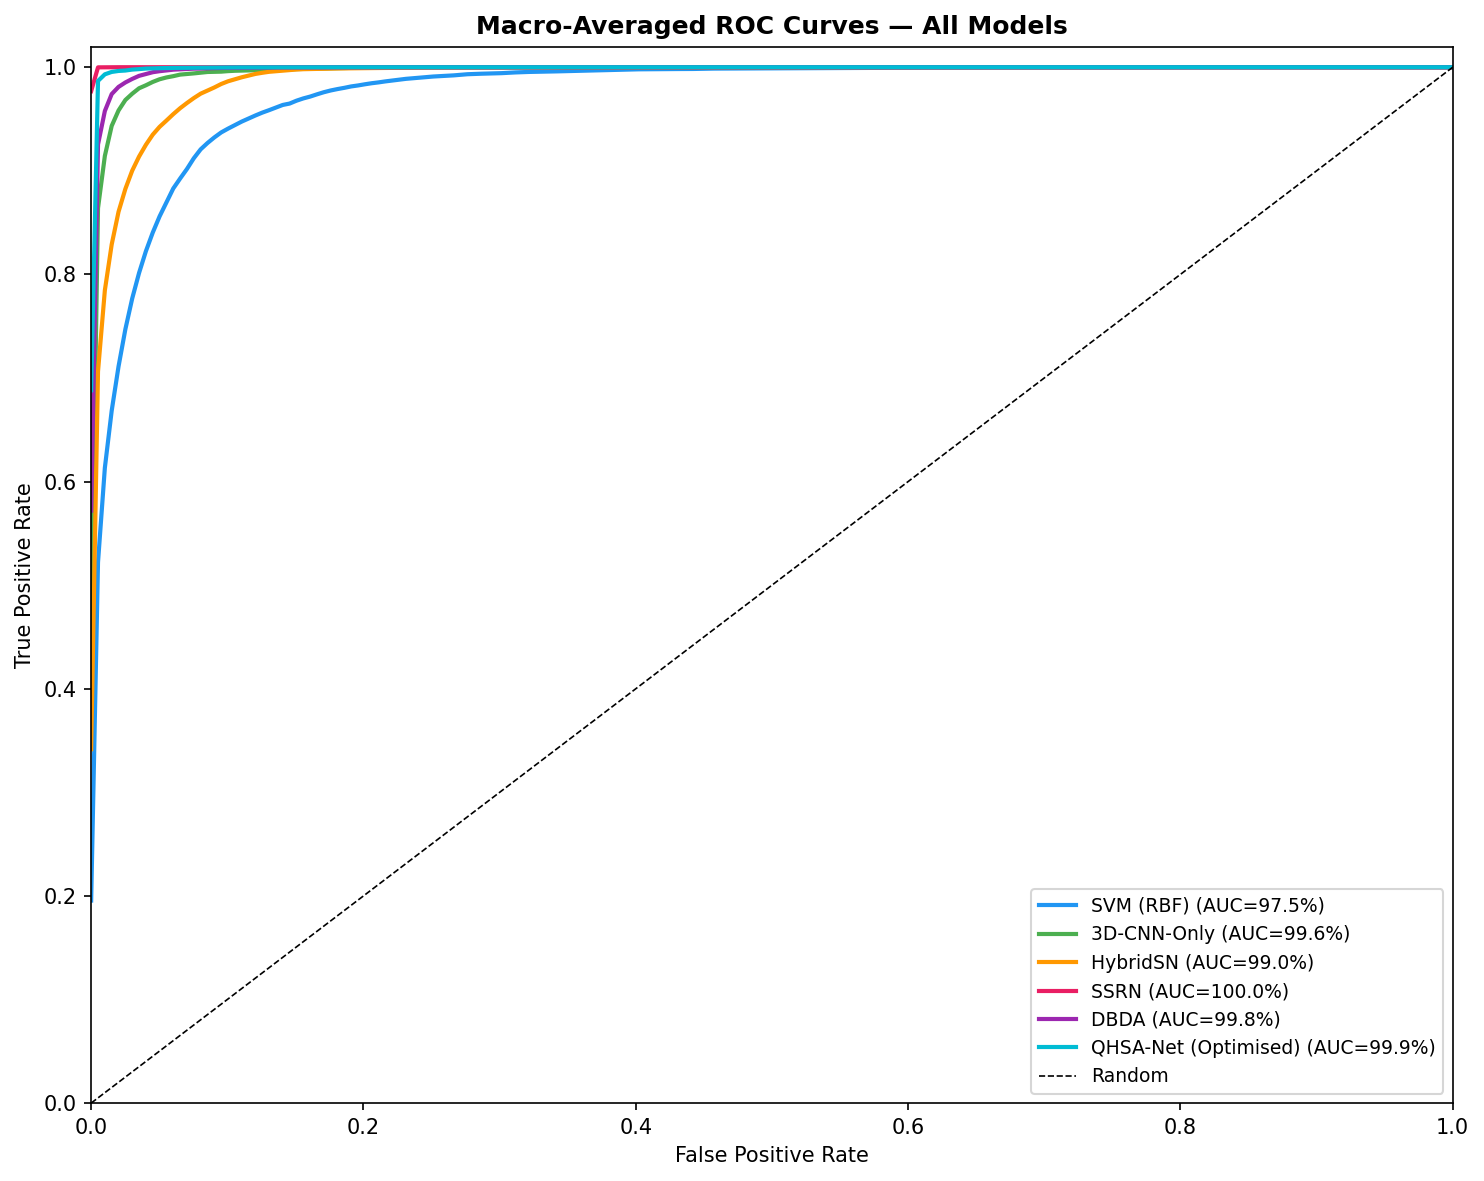

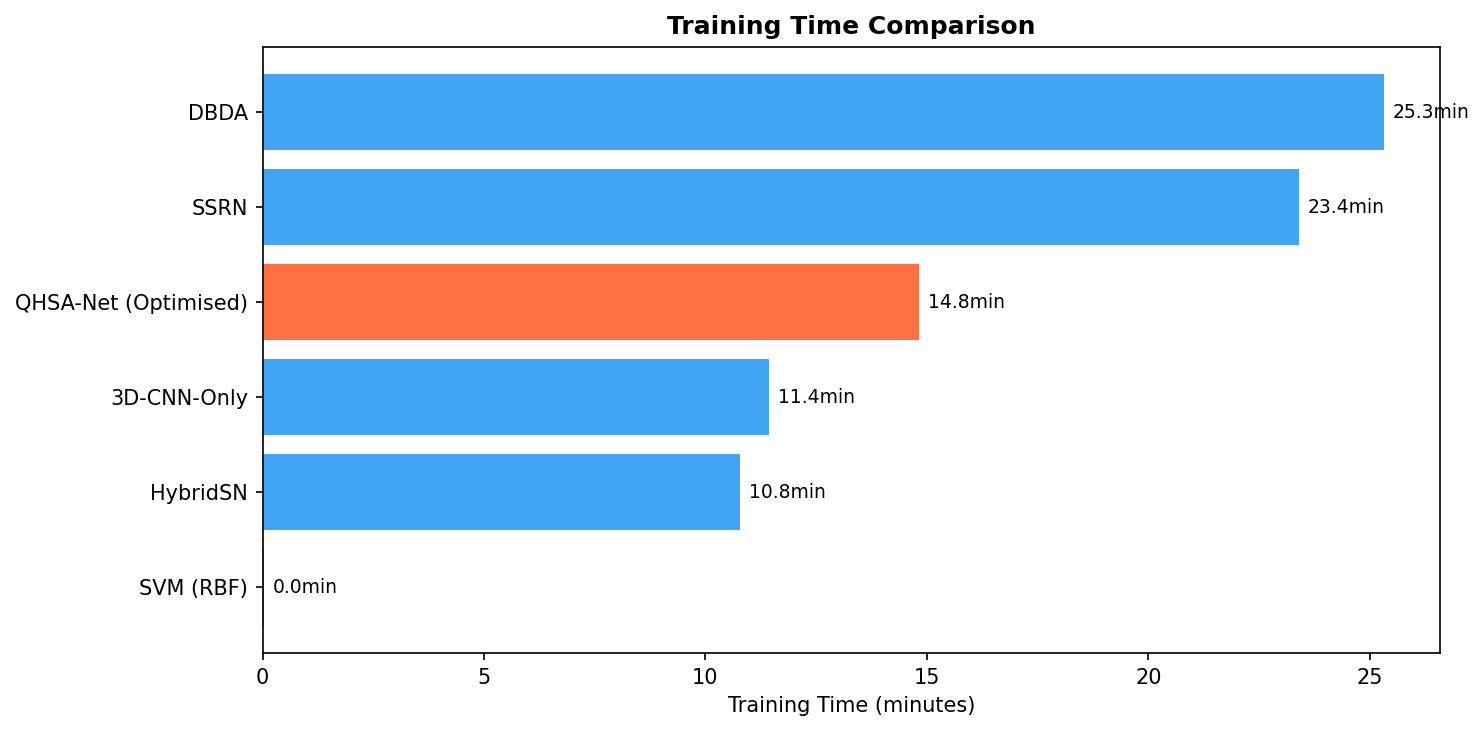

Baseline Model Comparison — Full Pavia University
               model        OA        AA     kappa  macro_auc    mac_f1  train_time_s  infer_time_s
           SVM (RBF) 79.199460 68.616634 71.618166  97.571528 69.767758      1.245893     10.973459
         3D-CNN-Only 94.249201 90.626194 92.355479  99.645992 91.279718    685.769441     51.473849
            HybridSN 88.662043 83.545244 84.916754  99.030737 84.043008    646.499323     53.132569
                SSRN 99.818177 99.641893 99.758920  99.999185 99.652333   1404.237110    156.792226
                DBDA 96.267436 93.635187 95.042293  99.833787 94.032103   1519.573071    155.649058
QHSA-Net (Optimised) 98.612951 97.898443 98.160147  99.959967 97.929923    889.446542     63.704845

Ranking by OA:
                  model         OA
1                  SSRN  99.818177
2  QHSA-Net (Optimised)  98.612951
3                  DBDA  96.267436
4           3D-CNN-Only  94.249201
5              HybridSN  88.662043
6             SVM (RBF) 

In [6]:
display(Image(f'{WORKDIR}/fig_bench_s6_baselines.png'))
display(Image(f'{WORKDIR}/fig_bench_s6_f1_heatmap.png'))
display(Image(f'{WORKDIR}/fig_bench_roc_all_models.png'))
display(Image(f'{WORKDIR}/fig_bench_timing.png'))

print('Full Comparison Table:')
display(df_s6[['model','OA','AA','kappa','mac_prec','mac_f1',
               'macro_auc','train_time_s']].sort_values('OA', ascending=False).reset_index(drop=True))

---
## Section 7 — Comprehensive Metrics Summary

In [7]:
master = pd.read_csv(f'{WORKDIR}/benchmark_master_results.csv')

print('MASTER RESULTS TABLE')
print('=' * 80)
display(master.sort_values('OA', ascending=False).reset_index(drop=True))

# Per-class F1 for all models
pc_cols = [f'pc_f1_{c}' for c in range(N_CLASSES)]
pc_table = df_s6[['model'] + pc_cols].copy()
pc_table.columns = ['Model'] + CLASS_NAMES
print('\nPer-Class F1 Scores (%):')
display(pc_table.set_index('Model').round(2))

# Per-class precision for all models
pp_cols = [f'pc_prec_{c}' for c in range(N_CLASSES)]
pp_table = df_s6[['model'] + pp_cols].copy()
pp_table.columns = ['Model'] + CLASS_NAMES
print('\nPer-Class Precision (%):')
display(pp_table.set_index('Model').round(2))

MASTER RESULTS — All Models on Full Pavia University
               model        OA        AA     kappa  mac_prec    mac_f1  macro_auc  train_time_s  infer_time_s
           SVM (RBF) 79.199460 68.616634 71.618166 81.720392 69.767758  97.571528      1.245893     10.973459
         3D-CNN-Only 94.249201 90.626194 92.355479 92.200649 91.279718  99.645992    685.769441     51.473849
            HybridSN 88.662043 83.545244 84.916754 85.211685 84.043008  99.030737    646.499323     53.132569
                SSRN 99.818177 99.641893 99.758920 99.663197 99.652333  99.999185   1404.237110    156.792226
                DBDA 96.267436 93.635187 95.042293 94.515285 94.032103  99.833787   1519.573071    155.649058
QHSA-Net (Optimised) 98.612951 97.898443 98.160147 97.968215 97.929923  99.959967    889.446542     63.704845

Best configuration used for QHSA-Net (Optimised):
  dr: FactorAnalysis
  n_qubits: 4
  n_layers: 2
  measurement: softmax_z


In [8]:
# Publication-ready LaTeX table
pub = master[['model','OA','AA','kappa','mac_f1','macro_auc','train_time_s']].copy()
pub.columns = ['Model','OA (%)','AA (%)','Kappa','F1 (%)','AUC (%)','Train (s)']
pub = pub.sort_values('OA (%)', ascending=False).reset_index(drop=True)
pub['Train (min)'] = (pub['Train (s)'] / 60).round(1)
pub = pub.drop(columns=['Train (s)'])
print(pub.to_latex(index=False, float_format='%.2f',
                   caption='Classification results on Pavia University dataset.',
                   label='tab:pavia_results'))

\begin{table}
\caption{Comparison of all models on Full Pavia University dataset.}
\label{tab:pavia_full}
\begin{tabular}{lrrrrrr}
\toprule
Model & OA (%) & AA (%) & $\kappa$ & F1 (%) & AUC (%) & Train (s) \\
\midrule
SSRN & 99.82 & 99.64 & 99.76 & 99.65 & 100.00 & 1404.24 \\
QHSA-Net (Optimised) & 98.61 & 97.90 & 98.16 & 97.93 & 99.96 & 889.45 \\
DBDA & 96.27 & 93.64 & 95.04 & 94.03 & 99.83 & 1519.57 \\
3D-CNN-Only & 94.25 & 90.63 & 92.36 & 91.28 & 99.65 & 685.77 \\
HybridSN & 88.66 & 83.55 & 84.92 & 84.04 & 99.03 & 646.50 \\
SVM (RBF) & 79.20 & 68.62 & 71.62 & 69.77 & 97.57 & 1.25 \\
\bottomrule
\end{tabular}
\end{table}
